In [42]:
from sklearn.neighbors import NearestNeighbors
import glob
import pandas as pd
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [43]:
barred_target = pd.read_csv('../data/matched_barred_ps1_resolved.csv')
unbarred_target = pd.read_csv('../data/matched_unbarred_ps1_resolved.csv')

In [44]:
target = pd.read_csv('../all_sample_20260702.csv')
target = pd.merge(target, barred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target = pd.merge(target, unbarred_target[['paliya_RA', 'class']], how='left', on='paliya_RA')
target['class'] = target['class_x'].combine_first(target['class_y'])
target = target.drop(['class_x', 'class_y'], axis=1)

target = target[target['class'].isin(['barred', 'unbarred'])]
tg_z = (target.paliya_Z).values
tg_d = Planck18.comoving_distance(target.paliya_Z).value
tg_ra = (target.paliya_RA).values
tg_dec = (target.paliya_DEC).values

coord = SkyCoord(ra = tg_ra * u.deg, dec = tg_dec * u.deg, distance = tg_d * u.Mpc)
tg_df = pd.DataFrame({'coord':coord})

In [54]:
from astropy.coordinates import Distance
from astropy.cosmology import z_at_value


def compute_index_for_target(i):
    file_list = glob.glob(f'../data/catalog/ps1/matched/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
    if len(file_list) == 0:
        return [-999]*3

    target_z = float(target.paliya_Z.iloc[i])
    df = pd.read_csv(file_list[0])
    # df = df[df.Absolute_Mag_r < -20.5]

    z_window = (
        z_at_value(Planck18.comoving_distance, (tg_d[i] + 5) * u.Mpc)
        - z_at_value(Planck18.comoving_distance, (tg_d[i] - 5) * u.Mpc)
    )
    # df = df[np.isfinite(df.z_phot0) & np.isfinite(df.z_photErr)]
    # df = df[np.abs(df.z_phot0 - target_z) < z_window]

    if len(df) == 0:
        return [-999]*3

    surround_z = df['z_phot0'].to_numpy(dtype=float)
    surround_err = df['z_photErr'].to_numpy(dtype=float)
    surround_ra = df.raMean.to_numpy(dtype=float)
    surround_dec = df.decMean.to_numpy(dtype=float)

    mask = (surround_z - surround_err / 2) > -1
    surround_z = surround_z[mask]
    surround_err = surround_err[mask]
    surround_ra = surround_ra[mask]
    surround_dec = surround_dec[mask]

    if len(surround_z) == 0:
        return [-999]*3

    surround_d = Planck18.comoving_distance(surround_z).value
    valid = np.isfinite(surround_d) & (surround_d >= 0)
    surround_z = surround_z[valid]
    surround_err = surround_err[valid]
    surround_ra = surround_ra[valid]
    surround_dec = surround_dec[valid]
    surround_d = surround_d[valid]

    if len(surround_d) == 0:
        return [-999]*3

    z_low = surround_z - surround_err / 2
    id = np.where(z_low < 0)
    z_low[id] = abs(surround_z[id] - surround_err[id] /2)
    z_low = Planck18.comoving_distance(z_low)
    z_low[id] = z_low[id] * -1
    surround_scale = (
        Planck18.comoving_distance(surround_z + surround_err / 2)
        - z_low
    ).value
    surround_odds = np.abs(
        norm.cdf(Planck18.comoving_distance(tg_z[i] + 1000/300000), loc=surround_d, scale=surround_scale)
        - norm.cdf(Planck18.comoving_distance(tg_z[i] - 1000/300000), loc=surround_d, scale=surround_scale)
    )

    z_mean = surround_z + tg_z[i]
    z_mean /= 2
    z_mean += 1
    scale = np.deg2rad((surround_d + tg_d[i])/z_mean)
    X = (surround_ra - tg_ra[i]) * np.cos(surround_dec - tg_dec[i]) * scale
    Y = (surround_dec - tg_dec[i]) * scale
    iteration = 100000
    
    def cal(_):
        mask_rd = np.full(len(X), False)
        while mask_rd[mask_rd == True].size < 3:
            rd = np.random.default_rng()
            rd = (np.max(surround_odds) - 0) * rd.random()
            mask_rd = surround_odds > rd
        xy = np.vstack([np.array([0, 0]), np.array([X[mask_rd], Y[mask_rd]]).T])
        from scipy.spatial import Voronoi, ConvexHull
        vor = Voronoi(xy)
        vertex_indices = vor.regions[vor.point_region[0]]
        if -1 in vertex_indices:
            return 0
        den = vor.vertices[vertex_indices]
        den = ConvexHull(den).volume
        return den
    density = Parallel(n_jobs = -1, verbose = 0)(delayed(cal)(_) for _ in range(iteration))
    # for _ in range(iteration):
    #     mask_rd = np.full(len(X), False)
    #     while mask_rd[mask_rd == True].size < 3:
    #         rd = np.random.default_rng()
    #         rd = (np.max(surround_odds) - 0) * rd.random()
    #         mask_rd = surround_odds > rd
    #     xy = np.vstack([np.array([0, 0]), np.array([X[mask_rd], Y[mask_rd]]).T])
    #     from scipy.spatial import Voronoi, ConvexHull
    #     vor = Voronoi(xy)
    #     vertex_indices = vor.regions[vor.point_region[0]]
    #     if -1 in vertex_indices:
    #         density.append(0)
    #         continue
    #     den = vor.vertices[vertex_indices]
    #     den = ConvexHull(den).volume
    #     density.append(den)
    voronoi_dens = 1/ np.mean(density)
    error = 0
    error_total = np.std(density)/np.sqrt(iteration)
    return [np.log10(voronoi_dens), error, error_total]
    # return density


dens = Parallel(n_jobs=-1, verbose=11)(delayed(compute_index_for_target)(i) for i in range(len(tg_df)))
dens = np.array([[dens[i][0], dens[i][1], dens[i][2], j] for i, j in enumerate(target['class'].values)])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   37.7s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   38.0s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:   39.9s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   43.9s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   44.3s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   53.8s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   59.8s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  

In [55]:
dens

array([['-0.9210639431161486', '0', '0.018916485122018843', 'barred'],
       ['-1.435789455381622', '0', '0.19301216335365803', 'barred'],
       ['-0.7681390514449693', '0', '0.03518583073186117', 'barred'],
       ['-1.7048892463372145', '0', '0.23098495448174627', 'unbarred'],
       ['-0.7521897624967866', '0', '0.02740213720553487', 'barred'],
       ['-1.066121405218537', '0', '0.030682513747119975', 'barred'],
       ['-1.0072353552264388', '0', '0.07001954246923119', 'unbarred'],
       ['-1.268004191493034', '0', '0.09013990371151381', 'unbarred'],
       ['-1.1095402292841596', '0', '0.05024366860134633', 'unbarred'],
       ['-1.3079112431509805', '0', '0.05302383125933613', 'unbarred'],
       ['-1.0613150832810236', '0', '0.045725211961109916', 'unbarred'],
       ['-0.9995154824946276', '0', '0.04075047487919288', 'unbarred'],
       ['-1.4221006934231109', '0', '0.08044276933447844', 'barred'],
       ['-2.1114914605329127', '0', '0.271742986480916', 'barred'],
       [

In [56]:
dens = dens[dens[:,0] != -999.0]

In [57]:
np.save('./STRM_dens.npy', dens)

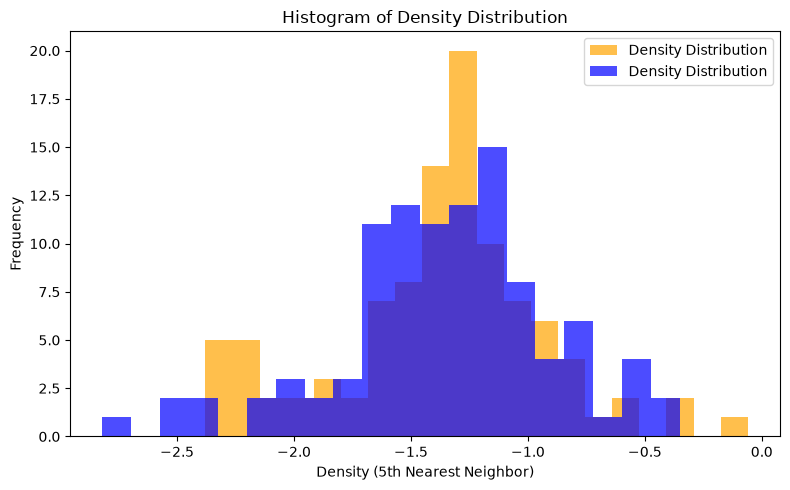

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist((dens[:,0][dens[:,-1] == 'barred'].astype(np.float64)), bins=20, label='Density Distribution', color='orange', alpha=0.7, cumulative=False)
plt.hist((dens[:,0][dens[:,-1] == 'unbarred'].astype(np.float64)), bins=20, label='Density Distribution', color='blue', alpha=0.7, cumulative=False)
plt.xlabel('Density (5th Nearest Neighbor)')
plt.ylabel('Frequency')
plt.title('Histogram of Density Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
plt.show()

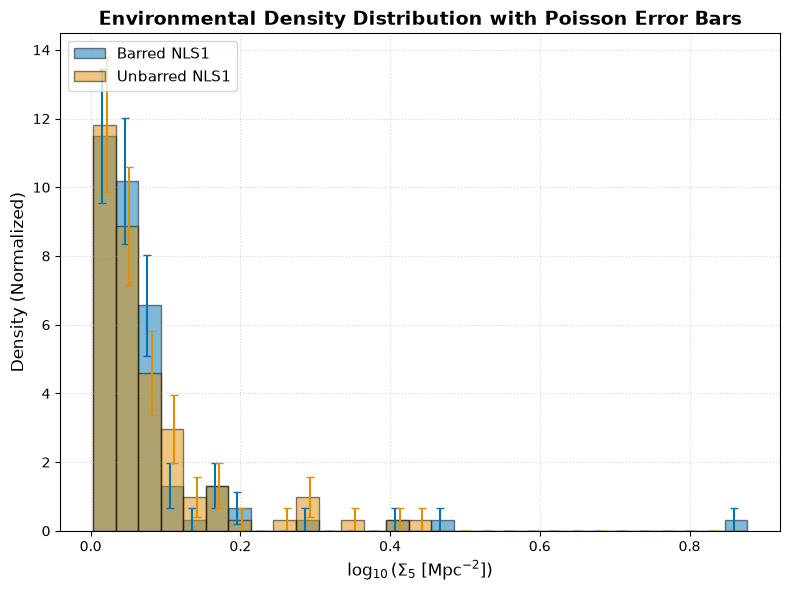

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 直接提取您的數據並轉為 float
b_dens = dens[:, 0][dens[:, -1] == 'barred'].astype(float)
ub_dens = dens[:, 0][dens[:, -1] == 'unbarred'].astype(float)

# 2. 完全交給算法自動決定最優分箱邊界 (bins='auto')，絕不人工限制
all_data = np.concatenate([b_dens, ub_dens])
bins = np.histogram_bin_edges(all_data, bins='auto')
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = np.diff(bins)  # 自動適應每個 bin 的實際寬度

# 3. 創建畫布
plt.figure(figsize=(8, 6))

# 4. 繪製標準的 overlapping plt.hist 並獲取每個 bin 的歸一化高度 (density=True)
b_heights, _, _ = plt.hist(b_dens, bins=bins, alpha=0.5, color='#0173b2', 
                           label='Barred NLS1', edgecolor='black', density=True)

ub_heights, _, _ = plt.hist(ub_dens, bins=bins, alpha=0.5, color='#de8f05', 
                            label='Unbarred NLS1', edgecolor='black', density=True)

# 5. 【拒絕任何 MC】直接解析計算每個 bin 的歸一化泊松誤差（Y 軸誤差棒）
# 獲取每個 bin 的原始星系計數 N
counts_b, _ = np.histogram(b_dens, bins=bins)
counts_ub, _ = np.histogram(ub_dens, bins=bins)

# 歸一化直方圖的泊松誤差公式： \sigma = \sqrt{N} / (N_total * bin_width)
b_bin_errs = np.sqrt(counts_b) / (len(b_dens) * bin_width)
ub_bin_errs = np.sqrt(counts_ub) / (len(ub_dens) * bin_width)

# 6. 在每個自動生成的柱子正上方繪製垂直誤差棒
# 左右微調 10% 的 bin 寬度，防止藍色和橙色的誤差棒完全重疊在一起
plt.errorbar(bin_centers - bin_width * 0.1, b_heights, yerr=b_bin_errs, 
             fmt='none', ecolor='#0173b2', elinewidth=1.5, capsize=3)

plt.errorbar(bin_centers + bin_width * 0.1, ub_heights, yerr=ub_bin_errs, 
             fmt='none', ecolor='#de8f05', elinewidth=1.5, capsize=3)

# 標籤與樣式 (使用 raw string 避免任何 SyntaxWarning)
plt.xlabel(r'$\log_{10}(\Sigma_5 \ [\mathrm{Mpc}^{-2}])$', fontsize=12)
plt.ylabel('Density (Normalized)', fontsize=12)
plt.title('Environmental Density Distribution with Poisson Error Bars', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# dens = []
# for i, idx in enumerate(index_arr):
#     if idx == -999:
#         continue
#     idx = int(idx)
#     file_list = glob.glob(f'../data/catalog/ps1/redshift_STRM/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
#     if len(file_list) == 0:
#         continue
#     df = pd.read_csv(file_list[0])
#     if idx >= len(df):
#         continue
#     row = df.distance_arcmin.iloc[idx] / 60
#     row = np.deg2rad(row)
#     fifth_dis = row * tg_d[i]
#     if fifth_dis <= 0 or not np.isfinite(fifth_dis):
#         continue
#     fifth_dens = 5 / np.pi / fifth_dis**2
#     fifth_dens = np.log(fifth_dens)
#     dens.append(fifth_dens)


In [ ]:
# plt.hist(dens, bins = 50, label = 'Density Distribution', color = 'blue', alpha = 0.7)
# plt.xlabel('Density (5th Nearest Neighbor)')
# plt.ylabel('Frequency')
# plt.title('Histogram of Density Distribution')
# plt.legend()
# plt.savefig('../fig/density_distribution_histogram_STRM.png', dpi=300)
# plt.show()